# ARLSTM Grid Sweep Multi-Model Evaluation

This notebook evaluates and compares **all 27 trained ARLSTM grid sweep models** stored locally in `model-runs/arlstm_grid_sweep/`.

### Hyperparameter Grid Axes Evaluated:
- **Learning Rate (`lr`)**: `0.0001`, `0.001`, `0.01`
- **Masking Fraction (`mf`)**: `0.1` (10%), `0.9` (90%), `0.99` (99%)
- **Hidden Size (`hs`)**: `128`, `256`, `512`
- **Random Seed (`seed`)**: `42`


In [1]:
%matplotlib inline
import os
import sys
import re
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import xarray as xr
from IPython.display import display, HTML

# Resolve repository root
cwd = Path(os.getcwd()).resolve()
repo_root = next(
    (p for p in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent, Path("/usr/local/google/home/kruparell/flood-forecasting")] if (p / "googlehydrology").is_dir() or (p / "tutorial").is_dir()),
    cwd
)
tut_dir = repo_root / "tutorial" if (repo_root / "tutorial").is_dir() else repo_root

for p in [str(repo_root), str(tut_dir), str(tut_dir / "scripts"), str(tut_dir / "notebooks")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from googlehydrology.utils.config import Config
from googlehydrology.modelzoo.arlstm import ARLSTM
from googlehydrology.evaluation.tester import RegressionTester
from googlehydrology.datasetzoo.multimet import _convert_to_tensor
from googlehydrology.evaluation.metrics import calculate_metrics, AllNaNError

def compute_hydro_metrics(obs_np, sim_np):
    if np.all(np.isnan(obs_np)) or np.all(np.isnan(sim_np)):
        return {"NSE": np.nan, "KGE": np.nan, "Pearson-r": np.nan, "RMSE": np.nan}
    obs_da = xr.DataArray(obs_np, dims=["date"])
    sim_da = xr.DataArray(sim_np, dims=["date"])
    try:
        return calculate_metrics(obs_da, sim_da, metrics=["NSE", "KGE", "Pearson-r", "RMSE"])
    except AllNaNError:
        return {"NSE": np.nan, "KGE": np.nan, "Pearson-r": np.nan, "RMSE": np.nan}
    except Exception:
        return {"NSE": np.nan, "KGE": np.nan, "Pearson-r": np.nan, "RMSE": np.nan}

plt.rcParams["font.size"] = 11
plt.rcParams["figure.figsize"] = (12, 6)
print("Environment and GoogleHydrology modules initialized successfully.")

Environment and GoogleHydrology modules initialized successfully.


## 1. Multi-Model Grid Sweep Evaluation Loop

We iterate through all local model directories in `model-runs/arlstm_grid_sweep/`, load configurations, scalers, and PyTorch checkpoints, run inference for both **Full Streamflow Input** and **Zero Streamflow Input**, and aggregate performance metrics.


In [2]:
t0 = time.time()
import subprocess
from googlehydrology.utils.gfile_utils import get_gfile
from googlehydrology.evaluation.tester import (
    RegressionTester, BasinBatchSampler, get_samples_indexes, 
    MultimetDataLoader, sort_frequencies, get_frequency_factor
)

gfile = get_gfile()

# Grid Sweep Directory (Prioritize Local copy if available for fast evaluation, fallback to CNS)
local_sweep_dir = repo_root / "model-runs" / "arlstm_masked_grid_sweep_v3"
cns_sweep_dir = Path("/cns/jn-d/home/floods/hydro_model/work/kruparell/arlstm_masked_results/arlstm_masked_grid_sweep_v3")

if local_sweep_dir.exists():
    grid_dir = local_sweep_dir
elif gfile.Exists(str(cns_sweep_dir)):
    grid_dir = cns_sweep_dir
else:
    grid_dir = repo_root / "model-runs" / "arlstm_grid_sweep"

if str(grid_dir).startswith("/cns/"):
    sweep_folders = sorted([Path(p) for p in gfile.Glob(f"{grid_dir}/*") if "lr" in Path(p).name])
else:
    sweep_folders = sorted([d for d in grid_dir.iterdir() if d.is_dir() and "lr" in d.name])

# Resolve model run directories
model_folders = []
for d in sweep_folders:
    if str(d).startswith("/cns/"):
        subdirs = [Path(p) for p in gfile.Glob(f"{d}/*") if gfile.Exists(f"{p}/config.yml")]
        if subdirs:
            model_folders.append(subdirs[-1])
        elif gfile.Exists(f"{d}/config.yml"):
            model_folders.append(d)
    else:
        subdirs = [p for p in d.iterdir() if p.is_dir() and (p / "config.yml").exists()]
        if subdirs:
            model_folders.append(subdirs[-1])
        elif (d / "config.yml").exists():
            model_folders.append(d)

# Fast Debug Settings: Set to None to evaluate all models and all basins
num_debug_models = None
num_debug_basins = 2

if num_debug_models is not None:
    model_folders = model_folders[:num_debug_models]

print(f"Evaluating {len(model_folders)} models in {grid_dir.name}...")

class ZeroDischargeModel(torch.nn.Module):
    """Wraps an ARLSTM model to mask out streamflow autoregressive features during inference,
    activating the model's internal autoregressive feedback simulation mode."""
    def __init__(self, base_model, mask_value=float('nan')):
        super().__init__()
        self.base_model = base_model
        self.mask_value = mask_value
        self.cfg = base_model.cfg
        self.output_size = base_model.output_size

    def pre_model_hook(self, data, is_train=False):
        data = self.base_model.pre_model_hook(data, is_train=is_train)
        for key in ["x_d_hindcast", "x_d"]:
            if key in data and isinstance(data[key], dict):
                for ar_name in ["streamflow_shift1", "streamflow"]:
                    if ar_name in data[key]:
                        data[key][ar_name] = torch.full_like(data[key][ar_name], self.mask_value)
        return data

    def forward(self, *args, **kwargs):
        return self.base_model(*args, **kwargs)

sweep_records = []
detailed_results = {}

for m_dir in model_folders:
    m_name = m_dir.name
    folder_str = m_dir.name if "lr" in m_dir.name else m_dir.parent.name
    match = re.search(r"lr([\d\.]+)_mf([\d\.]+)_hs(\d+)(?:_ep(\d+))?", folder_str)
    lr = float(match.group(1)) if match else None
    mf = float(match.group(2)) if match else None
    hs = int(match.group(3)) if match else None
    ep_val = int(match.group(4)) if (match and match.group(4)) else None

    # Determine local directory for saving test evaluation results
    if str(m_dir).startswith("/cns/"):
        local_run_dir = repo_root / "model-runs" / grid_dir.name / m_dir.parent.name / m_dir.name
    else:
        local_run_dir = m_dir
    local_run_dir.mkdir(parents=True, exist_ok=True)

    # Ensure config.yml, scaler.nc, and latest checkpoint exist locally
    if str(m_dir).startswith("/cns/"):
        if not (local_run_dir / "config.yml").exists() and gfile.Exists(f"{m_dir}/config.yml"):
            subprocess.run(["fileutil", "cp", f"{m_dir}/config.yml", f"{local_run_dir}/config.yml"], check=True)
        if not (local_run_dir / "scaler.nc").exists() and gfile.Exists(f"{m_dir}/scaler.nc"):
            subprocess.run(["fileutil", "cp", f"{m_dir}/scaler.nc", f"{local_run_dir}/scaler.nc"], check=True)

    pt_files = sorted(list(local_run_dir.glob("model_epoch*.pt")))
    if not pt_files and str(m_dir).startswith("/cns/"):
        cns_pts = sorted([Path(p) for p in gfile.Glob(f"{m_dir}/model_epoch*.pt")])
        if cns_pts:
            latest_ckpt = cns_pts[-1]
            local_pt = local_run_dir / latest_ckpt.name
            if not local_pt.exists():
                subprocess.run(["fileutil", "cp", str(latest_ckpt), str(local_pt)], check=True)
            pt_files = [local_pt]

    if not pt_files:
        continue
    latest_ckpt = pt_files[-1]

    ar_cfg = Config(local_run_dir / "config.yml")
    ar_cfg._cfg["run_dir"] = local_run_dir
    ar_cfg._cfg["base_run_dir"] = local_run_dir
    ar_cfg._cfg["verbose"] = 0
    if not Path(ar_cfg.statics_data_dir).exists():
        ar_cfg._cfg["statics_data_dir"] = Path("/usr/local/google/home/kruparell/Caravans_V2")
    if not Path(ar_cfg.dynamics_data_dir).exists():
        ar_cfg._cfg["dynamics_data_dir"] = Path("/usr/local/google/home/kruparell/Caravans_MultiMet")
    if not Path(ar_cfg.targets_data_dir).exists():
        ar_cfg._cfg["targets_data_dir"] = Path("/usr/local/google/home/kruparell/Caravans_V2")

    # Resolve 200-basin file
    basin_candidates = [
        local_run_dir / "sampled_task0_200basins_seed42.txt",
        local_run_dir.parent / "sampled_task0_200basins_seed42.txt",
        m_dir.parent / "sampled_task0_200basins_seed42.txt" if str(m_dir).startswith("/cns/") else None,
        cns_sweep_dir / m_dir.parent.name / "sampled_task0_200basins_seed42.txt",
    ]
    resolved_basin_file = next((p for p in basin_candidates if p is not None and gfile.Exists(str(p))), None)

    if resolved_basin_file:
        with gfile.GFile(str(resolved_basin_file), "r") as f:
            all_basins = [l.strip() if isinstance(l, str) else l.decode("utf-8").strip() for l in f.readlines() if l.strip()]
    else:
        all_basins = ["camelsaus_235205", "camelsaus_405226"]

    if num_debug_basins is not None:
        target_basins = all_basins[:num_debug_basins]
        temp_basin_file = tut_dir / "basin-lists" / f"temp_debug_{num_debug_basins}basins.txt"
        with open(temp_basin_file, "w") as f:
            f.write("\n".join(target_basins) + "\n")
        ar_cfg._cfg["test_basin_file"] = temp_basin_file
        ar_cfg._cfg["train_basin_file"] = temp_basin_file
    else:
        ar_cfg._cfg["test_basin_file"] = resolved_basin_file
        ar_cfg._cfg["train_basin_file"] = resolved_basin_file

    tester = RegressionTester(cfg=ar_cfg, run_dir=local_run_dir, period="test", init_model=True)
    tester.model.eval()

    # Search for existing zarr results locally or on CNS
    zarr_files = sorted(list((local_run_dir / "test").glob("*/test_results.zarr")))
    if not zarr_files and str(m_dir).startswith("/cns/"):
        zarr_files = sorted([Path(p) for p in gfile.Glob(f"{m_dir}/test/*/test_results.zarr")])
    
    zarr_path = zarr_files[-1] if zarr_files else None

    if zarr_path and gfile.Exists(str(zarr_path)):
        try:
            if str(zarr_path).startswith("/cns/"):
                with gfile.GFile(str(zarr_path), "rb") as f:
                    ds_check = xr.open_zarr(f, consolidated=False)
                    _ = ds_check["streamflow_obs"].shape
            else:
                ds_check = xr.open_zarr(zarr_path, consolidated=False)
                _ = ds_check["streamflow_obs"].shape
        except Exception as e:
            zarr_path = None

    if not zarr_path or not gfile.Exists(str(zarr_path)):
        tester.evaluate()
        zarr_files = sorted(list((local_run_dir / "test").glob("*/test_results.zarr")))
        zarr_path = zarr_files[-1] if zarr_files else None

    if zarr_path and gfile.Exists(str(zarr_path)):
        if str(zarr_path).startswith("/cns/"):
            with gfile.GFile(str(zarr_path), "rb") as f:
                ds_zarr = xr.open_zarr(f, consolidated=False).compute()
        else:
            ds_zarr = xr.open_zarr(zarr_path, consolidated=False).compute()

        basins = [str(b) for b in ds_zarr["basin"].values]
        if num_debug_basins is not None:
            basins = basins[:num_debug_basins]
        dates = pd.to_datetime(ds_zarr["date"].values)

        # Evaluate Without Streamflow Input using ZeroDischargeModel wrapper
        zero_model = ZeroDischargeModel(tester.model, mask_value=float('nan'))
        batch_sampler = BasinBatchSampler(
            sample_index=tester.dataset._sample_index,
            batch_size=max(tester.cfg.batch_size, 256),
            basins_indexes=get_samples_indexes(tester.basins, samples=list(basins)),
        )
        loader = MultimetDataLoader(
            tester.dataset,
            lazy_load=tester.cfg.lazy_load,
            logging_level=tester.cfg.logging_level,
            batch_sampler=batch_sampler,
            num_workers=0,
            collate_fn=tester.dataset.collate_fn,
        )
        freq = tester.dataset.frequencies[0]
        predict_last_n = tester.cfg.predict_last_n
        if isinstance(predict_last_n, int):
            predict_last_n = {freq: predict_last_n}
        lowest_freq = sort_frequencies(tester.dataset.frequencies)[0]
        frequency_factor = int(get_frequency_factor(lowest_freq, freq))

        zero_preds_dict = {}
        eval_it = tester._evaluate(zero_model, loader, tester.dataset.frequencies, set(basins))
        for b_data in eval_it:
            b_name = b_data["basin"]
            b_dates = b_data["dates"]
            data_vars = tester._create_xarray_data_vars(b_data["preds"][freq], b_data["obs"][freq])
            time_step_coords = (((b_dates[freq][0, :] - b_dates[freq][0, -1]) / pd.Timedelta(freq)).astype(np.int64) + frequency_factor - 1)
            date_coords = b_dates[lowest_freq][:, -1]
            if hasattr(tester.dataset, "lead_time") and tester.dataset.lead_time and predict_last_n[lowest_freq] > 1:
                time_step_coords += tester.dataset.lead_time
                idx = -tester.dataset.lead_time - 1
                if abs(idx) <= b_dates[lowest_freq].shape[1]:
                    date_coords = b_dates[lowest_freq][:, idx]
                else:
                    date_coords = b_dates[lowest_freq][:, 0]
            coords = {"date": date_coords, "time_step": time_step_coords}
            xr_ds = xr.Dataset(data_vars=data_vars, coords=coords)
            xr_ds = xr_ds.reindex({"date": pd.DatetimeIndex(pd.date_range(xr_ds["date"].values[0], xr_ds["date"].values[-1], freq=lowest_freq), name="date")})
            xr_ds = tester.dataset.scaler.unscale(xr_ds)
            zero_preds_dict[b_name] = np.maximum(0.0, xr_ds["streamflow_sim"].isel(time_step=0).values.flatten())

        nse_full_list, nse_zero_list = [], []
        kge_full_list, kge_zero_list = [], []
        predictions_dict = {}
        for b in basins:
            obs = ds_zarr["streamflow_obs"].sel(basin=b).isel(freq=0, time_step=0).values.flatten()
            sim_full = np.maximum(0.0, ds_zarr["streamflow_sim"].sel(basin=b).isel(freq=0, time_step=0).values.flatten())
            sim_zero = zero_preds_dict.get(b, np.full_like(obs, np.nan))

            m_full = compute_hydro_metrics(obs, sim_full)
            m_zero = compute_hydro_metrics(obs, sim_zero)

            nse_full_list.append(m_full["NSE"])
            nse_zero_list.append(m_zero["NSE"])
            kge_full_list.append(m_full["KGE"])
            kge_zero_list.append(m_zero["KGE"])
            predictions_dict[b] = {"dates": dates, "obs": obs, "sim_full": sim_full, "sim_zero": sim_zero}

        rec = {
            "Model": m_name,
            "Learning Rate": lr,
            "Masking Fraction": mf,
            "Hidden Size": hs,
            "Median NSE (Full)": np.median(nse_full_list),
            "Mean NSE (Full)": np.mean(nse_full_list),
            "Median KGE (Full)": np.median(kge_full_list),
            "Median NSE (Zero)": np.median(nse_zero_list),
            "Mean NSE (Zero)": np.mean(nse_zero_list),
            "Median KGE (Zero)": np.median(kge_zero_list),
            "NSE Degradation (Full-Zero)": np.median(nse_full_list) - np.median(nse_zero_list),
        }
        if ep_val is not None:
            rec["Epochs"] = ep_val
        sweep_records.append(rec)
        detailed_results[m_name] = {"nse_full": nse_full_list, "nse_zero": nse_zero_list, "predictions": predictions_dict}

df_sweep = pd.DataFrame(sweep_records).sort_values(by="Median NSE (Full)", ascending=False)
elapsed = time.time() - t0
print(f"Evaluated {len(df_sweep)} models in {elapsed:.2f}s.")
display(df_sweep.round(4))

Evaluating 12 models in arlstm_masked_grid_sweep_v3...


Evaluated 12 models in 59.72s.


,Model,Learning Rate,Masking Fraction,Hidden Size,Median NSE (Full),Mean NSE (Full),Median KGE (Full),Median NSE (Zero),Mean NSE (Zero),Median KGE (Zero),NSE Degradation (Full-Zero),Epochs
1,arlstm-200basin-masked_99pct_0608_102224,0.0001,0.99,256,0.3472,0.3472,0.3390,-24.7215,-24.7215,-16.2271,25.0687,30
0,arlstm-200basin-masked_99pct_0608_102224,0.0001,0.99,256,0.3064,0.3064,0.2769,-31.1025,-31.1025,-18.1010,31.4090,15
8,arlstm-200basin-masked_99pct_0608_102400,0.0010,0.99,256,0.1985,0.1985,0.0395,-10.2592,-10.2592,-10.4302,10.4577,5
11,arlstm-200basin-masked_99pct_0608_102238,0.0010,0.99,512,0.1606,0.1606,-0.0656,-26.8125,-26.8125,-16.7732,26.9731,5
10,arlstm-200basin-masked_99pct_0608_102343,0.0010,0.99,512,0.1297,0.1297,-0.3343,-2.4919,-2.4919,-5.0318,2.6216,30
2,arlstm-200basin-masked_99pct_0608_102239,0.0001,0.99,256,0.1005,0.1005,-0.4271,-1.1300,-1.1300,-3.2434,1.2306,5
3,arlstm-200basin-masked_99pct_0608_102343,0.0001,0.99,512,0.0710,0.0710,-0.3429,-18.8507,-18.8507,-14.0053,18.9217,15
7,arlstm-200basin-masked_99pct_0708_021513,0.0010,0.99,256,0.0587,0.0587,-0.2784,-20.1691,-20.1691,-14.6556,20.2278,30
5,arlstm-200basin-masked_99pct_0608_102140,0.0001,0.99,512,0.0469,0.0469,-0.5696,-3.0188,-3.0188,-5.5047,3.0656,5
9,arlstm-200basin-masked_99pct_0608_102440,0.0010,0.99,512,0.0412,0.0412,-0.4940,-6.1117,-6.1117,-7.9798,6.1528,15


## 2. Hyperparameter Performance Heatmaps

Visualizing **Median NSE (Full Input)** across Learning Rate ($Y$-axis) and Masking Fraction ($X$-axis), faceted by Hidden Size.


In [3]:
hidden_sizes = sorted(df_sweep["Hidden Size"].dropna().unique())
if not hidden_sizes:
    hidden_sizes = [0]

fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(6 * len(hidden_sizes), 5), sharey=True, squeeze=False)
fig.patch.set_facecolor("white")

for i, hs_val in enumerate(hidden_sizes):
    sub_df = df_sweep[df_sweep["Hidden Size"] == hs_val] if hs_val != 0 else df_sweep.copy()
    if "Epochs" in sub_df.columns and sub_df["Epochs"].nunique() > 1:
        sub_df = sub_df.sort_values("Epochs").groupby(["Learning Rate", "Masking Fraction"]).last().reset_index()
    if not sub_df.empty:
        pivot = sub_df.pivot(index="Learning Rate", columns="Masking Fraction", values="Median NSE (Full)")
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0, i], cbar=(i == len(hidden_sizes)-1), vmin=0.0, vmax=1.0)
    axes[0, i].set_title(f"Hidden Size = {hs_val}", fontweight="bold")
    axes[0, i].set_xlabel("Masking Fraction", fontweight="bold")
    if i == 0:
        axes[0, i].set_ylabel("Learning Rate", fontweight="bold")

plt.suptitle("ARLSTM Grid Sweep: Median NSE (Full River Discharge Input)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_4163950/2434460559.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 3. Robustness Analysis: Full vs. Zero Discharge Input

Analyzing how masking fraction during training impacts model reliance on autoregressive streamflow inputs during inference.


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")

hue_col = "Epochs" if ("Epochs" in df_sweep.columns and df_sweep["Epochs"].nunique() > 1) else "Hidden Size"

sns.barplot(data=df_sweep, x="Masking Fraction", y="NSE Degradation (Full-Zero)", hue=hue_col, palette="viridis", ax=ax)
ax.set_title("NSE Performance Degradation when Autoregressive Input is Zeroed Out", fontweight="bold", fontsize=13)
ax.set_xlabel("Training Masking Fraction", fontweight="bold")
ax.set_ylabel("NSE Drop (Median NSE Full - Median NSE Zero)", fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4163950/2501393941.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4. Top Performing Models Summary


In [5]:
print("=== TOP 5 ARLSTM MODELS (RANKED BY MEDIAN NSE FULL INPUT) ===")
cols_to_show = ["Model", "Learning Rate", "Masking Fraction", "Hidden Size"]
if "Epochs" in df_sweep.columns:
    cols_to_show.append("Epochs")
cols_to_show.extend(["Median NSE (Full)", "Median NSE (Zero)", "NSE Degradation (Full-Zero)"])
display(df_sweep.head(5)[cols_to_show].round(4))

=== TOP 5 ARLSTM MODELS (RANKED BY MEDIAN NSE FULL INPUT) ===


,Model,Learning Rate,Masking Fraction,Hidden Size,Epochs,Median NSE (Full),Median NSE (Zero),NSE Degradation (Full-Zero)
1,arlstm-200basin-masked_99pct_0608_102224,0.0001,0.99,256,30,0.3472,-24.7215,25.0687
0,arlstm-200basin-masked_99pct_0608_102224,0.0001,0.99,256,15,0.3064,-31.1025,31.4090
8,arlstm-200basin-masked_99pct_0608_102400,0.0010,0.99,256,5,0.1985,-10.2592,10.4577
11,arlstm-200basin-masked_99pct_0608_102238,0.0010,0.99,512,5,0.1606,-26.8125,26.9731
10,arlstm-200basin-masked_99pct_0608_102343,0.0010,0.99,512,30,0.1297,-2.4919,2.6216


## 5. Hydrograph Comparison: Top N Models

Function to plot hydrographs comparing the **observed streamflow** against the **top N models** with full river discharge input (left) and zero river discharge input (right).


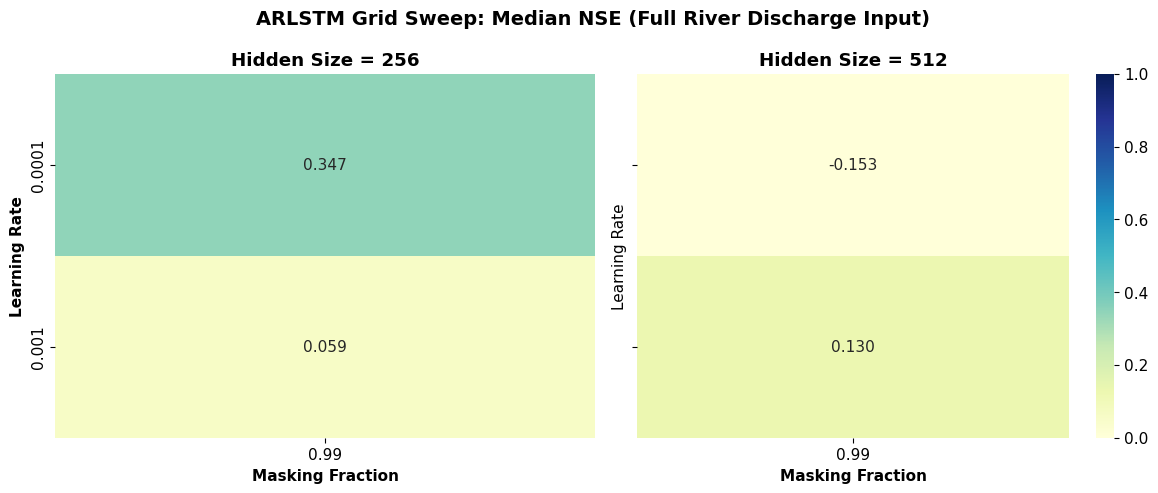

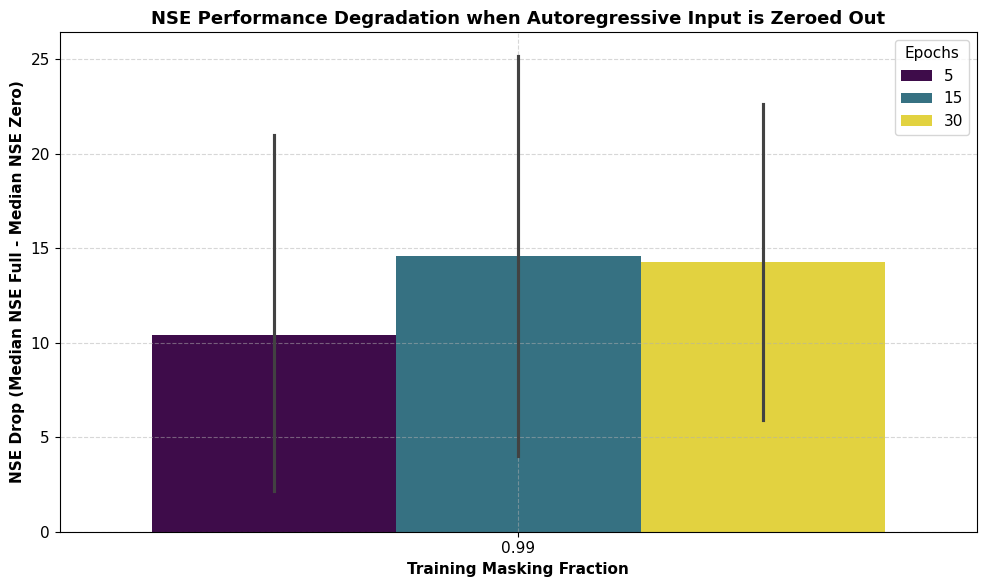

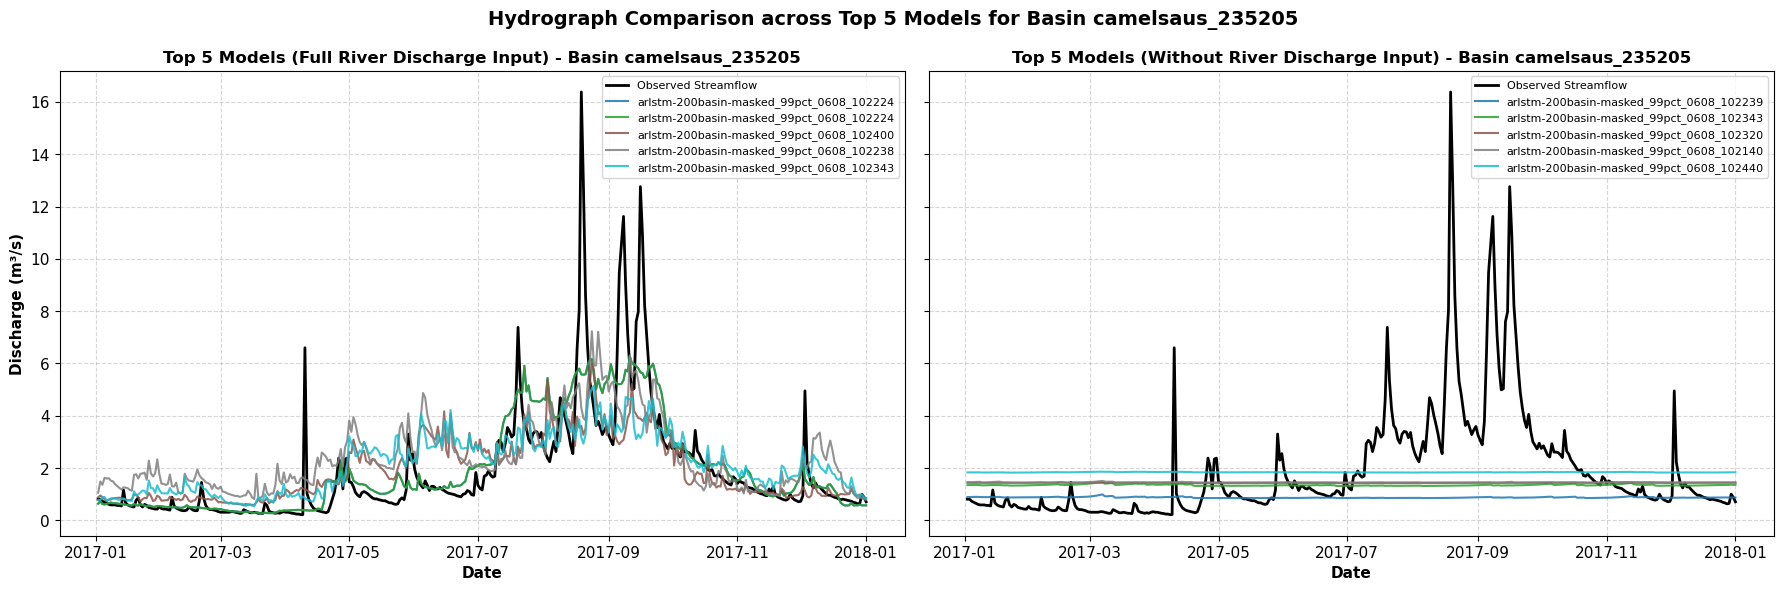

In [6]:
%matplotlib inline
def plot_top_model_hydrographs(df_sweep, detailed_results, basin_id=None, top_n=5, plot_length=None):
    """Plots hydrograph comparisons for top_n models with and without river discharge input."""
    if df_sweep.empty:
        print("No models available in df_sweep to plot.")
        return

    n_models = min(top_n, len(df_sweep))
    top_full_models = df_sweep.sort_values(by="Median NSE (Full)", ascending=False).head(n_models)["Model"].tolist()
    top_zero_models = df_sweep.sort_values(by="Median NSE (Zero)", ascending=False).head(n_models)["Model"].tolist()

    first_model = top_full_models[0]
    available_basins = list(detailed_results[first_model]["predictions"].keys())
    if basin_id is None or basin_id not in available_basins:
        basin_id = available_basins[0]

    sample_data = detailed_results[first_model]["predictions"][basin_id]
    dates = sample_data["dates"]
    obs = sample_data["obs"]

    if plot_length is None or plot_length > len(dates):
        plot_len = len(dates)
    else:
        plot_len = plot_length

    eval_dates = dates[:plot_len]
    eval_obs = obs[:plot_len]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    fig.patch.set_facecolor("white")
    colors = plt.cm.tab10(np.linspace(0, 1, n_models))

    # --- Left Subplot: Full Discharge Input ---
    ax_left = axes[0]
    ax_left.plot(eval_dates, eval_obs, color="black", linewidth=2.0, label="Observed Streamflow", linestyle="-")
    for idx, m_name in enumerate(top_full_models):
        pred = detailed_results[m_name]["predictions"][basin_id]
        ax_left.plot(eval_dates, pred["sim_full"][:plot_len], label=f"{m_name}", color=colors[idx], linewidth=1.5, alpha=0.85)

    ax_left.set_title(f"Top {n_models} Models (Full River Discharge Input) - Basin {basin_id}", fontweight="bold", fontsize=12)
    ax_left.set_xlabel("Date", fontweight="bold")
    ax_left.set_ylabel("Discharge (m³/s)", fontweight="bold")
    ax_left.legend(loc="upper right", fontsize=8)
    ax_left.grid(True, linestyle="--", alpha=0.5)

    # --- Right Subplot: Zero / Missing Discharge Input ---
    ax_right = axes[1]
    ax_right.plot(eval_dates, eval_obs, color="black", linewidth=2.0, label="Observed Streamflow", linestyle="-")
    for idx, m_name in enumerate(top_zero_models):
        pred = detailed_results[m_name]["predictions"][basin_id]
        ax_right.plot(eval_dates, pred["sim_zero"][:plot_len], label=f"{m_name}", color=colors[idx], linewidth=1.5, alpha=0.85)

    ax_right.set_title(f"Top {n_models} Models (Without River Discharge Input) - Basin {basin_id}", fontweight="bold", fontsize=12)
    ax_right.set_xlabel("Date", fontweight="bold")
    ax_right.legend(loc="upper right", fontsize=8)
    ax_right.grid(True, linestyle="--", alpha=0.5)

    plt.suptitle(f"Hydrograph Comparison across Top {n_models} Models for Basin {basin_id}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Example Call: Plot Top 5 Models over sequence period
plot_top_model_hydrographs(df_sweep, detailed_results, top_n=5)